<a href="https://colab.research.google.com/github/aaronbinoy/Code-a-Pookalam/blob/main/Code_a_Pookalam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

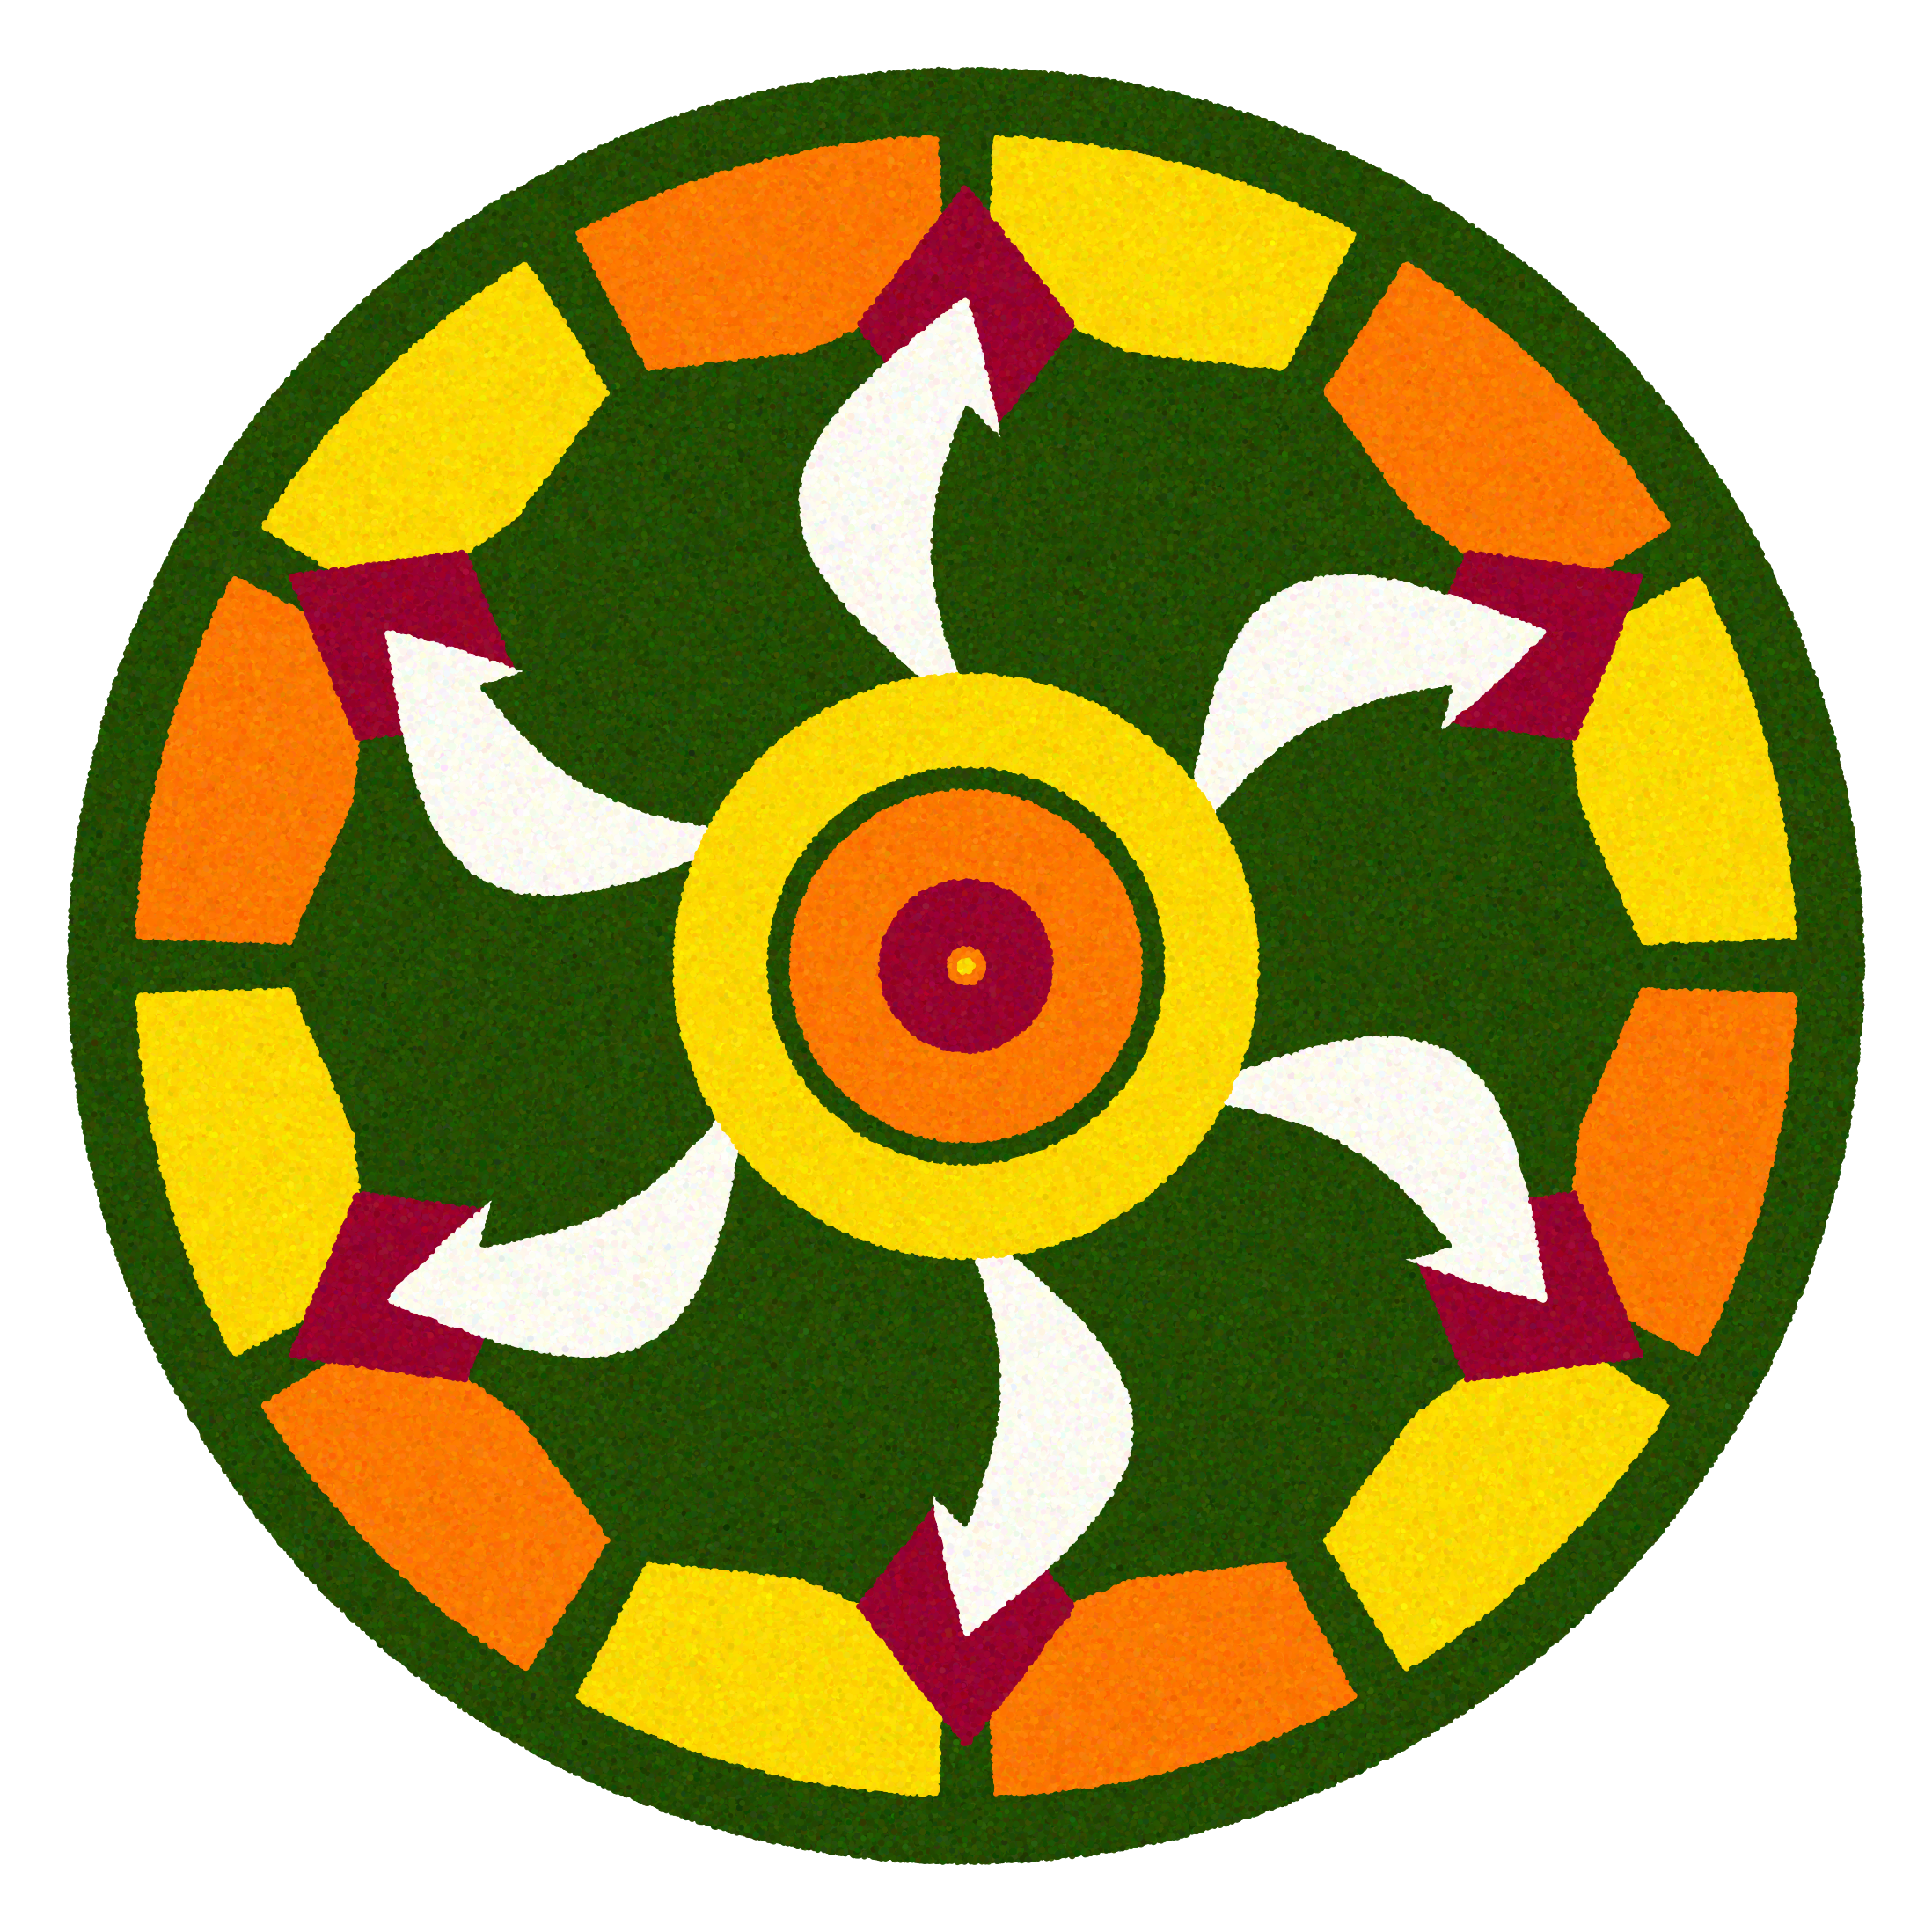

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import numpy as np

# ==========================================================
# POOKALAM SIMULATION
# Reference style:
# Green circular border + alternating yellow/orange wedges
# + maroon diamonds + large white curved petals
# + green inner petals + concentric floral centre
# ==========================================================

np.random.seed(42)

# ----------------------------------------------------------
# CANVAS
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 12), dpi=180)

ax.set_aspect("equal")
ax.axis("off")

fig.patch.set_facecolor("white")
ax.set_facecolor("white")


# ----------------------------------------------------------
# COLOUR PALETTE
# ----------------------------------------------------------

C_GREEN  = "#244d00"
C_GREEN2 = "#315f00"

C_YELLOW = "#ffd900"
C_ORANGE = "#ff7900"

C_MAROON = "#98002e"
C_RED    = "#b00032"

C_WHITE  = "#fffdf1"


# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def add_textured_polygon(
    ax,
    x,
    y,
    color,
    density=1.5,
    particle_min=3,
    particle_max=10,
    zorder=1
):
    """
    Creates a solid polygon and overlays thousands of
    randomized particles to imitate flower petals.
    """

    xy = np.column_stack([x, y])

    poly = patches.Polygon(
        xy,
        closed=True,
        facecolor=color,
        edgecolor=color,
        linewidth=0.4,
        zorder=zorder
    )

    ax.add_patch(poly)

    path = poly.get_path()

    min_x, max_x = np.min(x), np.max(x)
    min_y, max_y = np.min(y), np.max(y)

    area = max((max_x - min_x) * (max_y - min_y), 0)

    n = int(area * density * 650)

    if n <= 0:
        return

    rx = np.random.uniform(min_x, max_x, n)
    ry = np.random.uniform(min_y, max_y, n)

    pts = np.column_stack([rx, ry])

    inside = path.contains_points(pts)

    px = rx[inside]
    py = ry[inside]

    if len(px) == 0:
        return

    base_rgb = np.array(plt.matplotlib.colors.to_rgb(color))

    noise = np.random.normal(
        0,
        0.035,
        size=(len(px), 3)
    )

    particle_colors = np.clip(
        base_rgb + noise,
        0,
        1
    )

    ax.scatter(
        px,
        py,
        s=np.random.uniform(
            particle_min,
            particle_max,
            len(px)
        ),
        c=particle_colors,
        marker="o",
        linewidths=0,
        alpha=0.95,
        zorder=zorder + 0.1
    )


def add_textured_circle(
    ax,
    cx,
    cy,
    radius,
    color,
    density=2,
    zorder=1
):

    t = np.linspace(
        0,
        2*np.pi,
        150
    )

    x = cx + radius*np.cos(t)
    y = cy + radius*np.sin(t)

    add_textured_polygon(
        ax,
        x,
        y,
        color,
        density=density,
        zorder=zorder
    )


def add_textured_ring(
    ax,
    r_outer,
    r_inner,
    color,
    density=2,
    zorder=1
):

    t = np.linspace(
        0,
        2*np.pi,
        220
    )

    xo = r_outer*np.cos(t)
    yo = r_outer*np.sin(t)

    xi = r_inner*np.cos(t[::-1])
    yi = r_inner*np.sin(t[::-1])

    x = np.concatenate([xo, xi])
    y = np.concatenate([yo, yi])

    add_textured_polygon(
        ax,
        x,
        y,
        color,
        density=density,
        zorder=zorder
    )


# ----------------------------------------------------------
# CURVED PETAL
# ----------------------------------------------------------

def petal_points(
    angle,
    r_inner=3.0,
    r_outer=7.0,
    width=1.4,
    curve=0.8,
    n=80
):
    """
    Generates a curved leaf/petal pointing radially outward.
    """

    # Local coordinate system
    u = np.linspace(0, 1, n)

    # radial coordinate
    r = r_inner + (r_outer - r_inner)*u

    # petal width:
    # narrow at both ends and thick in middle
    w = width * np.sin(np.pi*u)

    # curvature offset
    bend = curve * np.sin(np.pi*u)

    # left side
    x1 = r
    y1 = w + bend

    # right side
    x2 = r[::-1]
    y2 = (-w + bend)[::-1]

    x_local = np.concatenate([x1, x2])
    y_local = np.concatenate([y1, y2])

    c = np.cos(angle)
    s = np.sin(angle)

    x = x_local*c - y_local*s
    y = x_local*s + y_local*c

    return x, y


# ----------------------------------------------------------
# DIAMOND / LEAF SHAPE
# ----------------------------------------------------------

def diamond_points(
    angle,
    r_center=7.2,
    radial_size=1.55,
    tangential_size=1.25
):

    center = np.array([
        r_center*np.cos(angle),
        r_center*np.sin(angle)
    ])

    radial = np.array([
        np.cos(angle),
        np.sin(angle)
    ])

    tangent = np.array([
        -np.sin(angle),
        np.cos(angle)
    ])

    p1 = center + radial*radial_size
    p2 = center + tangent*tangential_size
    p3 = center - radial*radial_size
    p4 = center - tangent*tangential_size

    pts = np.array([p1, p2, p3, p4])

    return pts[:, 0], pts[:, 1]


# ==========================================================
# 1. BASE GREEN DISC
# ==========================================================

add_textured_circle(
    ax,
    0,
    0,
    10,
    C_GREEN,
    density=2.2,
    zorder=1
)


# ==========================================================
# 2. OUTER GREEN BORDER
# ==========================================================

add_textured_ring(
    ax,
    10.0,
    9.35,
    C_GREEN,
    density=2.8,
    zorder=2
)


# ==========================================================
# 3. ALTERNATING YELLOW / ORANGE OUTER WEDGES
# ==========================================================

N_WEDGES = 12

r_outer = 9.25
r_inner = 7.55

for i in range(N_WEDGES):

    a1 = 2*np.pi*i/N_WEDGES
    a2 = 2*np.pi*(i+1)/N_WEDGES

    # slight gap to expose green separators
    gap = 0.035

    aa1 = a1 + gap
    aa2 = a2 - gap

    t = np.linspace(
        aa1,
        aa2,
        30
    )

    x_outer = r_outer*np.cos(t)
    y_outer = r_outer*np.sin(t)

    # central inner tip
    amid = (aa1 + aa2)/2

    inner_left = np.array([
        r_inner*np.cos(aa2),
        r_inner*np.sin(aa2)
    ])

    inner_tip = np.array([
        7.10*np.cos(amid),
        7.10*np.sin(amid)
    ])

    inner_right = np.array([
        r_inner*np.cos(aa1),
        r_inner*np.sin(aa1)
    ])

    x = np.concatenate([
        x_outer,
        [
            inner_left[0],
            inner_tip[0],
            inner_right[0]
        ]
    ])

    y = np.concatenate([
        y_outer,
        [
            inner_left[1],
            inner_tip[1],
            inner_right[1]
        ]
    ])

    col = (
        C_YELLOW
        if i % 2 == 0
        else C_ORANGE
    )

    add_textured_polygon(
        ax,
        x,
        y,
        col,
        density=2.5,
        particle_min=4,
        particle_max=11,
        zorder=3
    )


# ==========================================================
# 4. MAROON DIAMOND / LEAF SHAPES
# ==========================================================

N_DIAMONDS = 6

for i in range(N_DIAMONDS):

    angle = (
        2*np.pi*i/N_DIAMONDS
        + np.pi/2
    )

    x, y = diamond_points(
        angle,
        r_center=7.15,
        radial_size=1.55,
        tangential_size=1.2
    )

    add_textured_polygon(
        ax,
        x,
        y,
        C_MAROON,
        density=3.0,
        particle_min=4,
        particle_max=11,
        zorder=4
    )


# ==========================================================
# 5. LARGE WHITE CURVED FLOWER PETALS
# ==========================================================

N_WHITE = 6

for i in range(N_WHITE):

    angle = (
        2*np.pi*i/N_WHITE
        + np.pi/6
    )

    x, y = petal_points(
        angle,
        r_inner=2.85,
        r_outer=7.45,
        width=1.12,
        curve=0.72,
        n=120
    )

    add_textured_polygon(
        ax,
        x,
        y,
        C_WHITE,
        density=3.2,
        particle_min=5,
        particle_max=12,
        zorder=5
    )


# ==========================================================
# 6. INNER GREEN POINTED PETALS
# ==========================================================

N_GREEN_PETALS = 6

for i in range(N_GREEN_PETALS):

    angle = (
        2*np.pi*i/N_GREEN_PETALS
        + np.pi/6
    )

    # slightly narrower green petal
    x, y = petal_points(
        angle,
        r_inner=3.05,
        r_outer=6.25,
        width=0.72,
        curve=-0.35,
        n=100
    )

    add_textured_polygon(
        ax,
        x,
        y,
        C_GREEN,
        density=2.6,
        particle_min=3,
        particle_max=8,
        zorder=6
    )


# ==========================================================
# 7. CENTRAL YELLOW RING
# ==========================================================

add_textured_circle(
    ax,
    0,
    0,
    3.25,
    C_YELLOW,
    density=3.0,
    zorder=7
)


# ==========================================================
# 8. DARK GREEN THIN SEPARATION RING
# ==========================================================

add_textured_ring(
    ax,
    2.20,
    1.95,
    C_GREEN,
    density=3.0,
    zorder=8
)


# ==========================================================
# 9. ORANGE INNER DISC
# ==========================================================

add_textured_circle(
    ax,
    0,
    0,
    1.95,
    C_ORANGE,
    density=3.5,
    zorder=9
)


# ==========================================================
# 10. MAROON INNER DISC
# ==========================================================

add_textured_circle(
    ax,
    0,
    0,
    0.95,
    C_MAROON,
    density=4.0,
    zorder=10
)


# ==========================================================
# 11. TINY ORANGE/YELLOW CENTRE
# ==========================================================

add_textured_circle(
    ax,
    0,
    0,
    0.20,
    C_ORANGE,
    density=5,
    zorder=11
)

add_textured_circle(
    ax,
    0,
    0,
    0.075,
    C_YELLOW,
    density=5,
    zorder=12
)


# ==========================================================
# FINAL VIEW
# ==========================================================

ax.set_xlim(-10.6, 10.6)
ax.set_ylim(-10.6, 10.6)

plt.tight_layout(pad=0)

plt.show()